# Custom CSP vs MNE — Phase 3.3

**Goal:** Check that `src.csp.CSP` agrees with the reference `mne.decoding.CSP` on the same epochs.

**What should match:** classification accuracy (same ballpark).  
**What will not match 1:1:** raw filter coefficients and feature values.

| Difference | Why |
|---|---|
| Eigenvector **sign** | If `w` is a filter, so is `-w`. |
| Component **order** | MNE `alternate` interleaves large / small λ; ours keeps the large ones then the small ones. |
| `transform` formula | MNE: `log(mean(Z²))`. Ours: `log(var / Σ var)`. |
| Linear algebra path | MNE uses a generalised eigendecomposition; ours whitens then eigendecomposes. |

The subject only asks that our transformer be sklearn-compatible and useful for classification — not a bit-exact clone of MNE.


### Imports

In [1]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
from mne.decoding import CSP as MneCSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

mne.set_log_level("ERROR")

ROOT = Path("..") if not Path("src").exists() else Path(".")
sys.path.insert(0, str(ROOT.resolve()))

from src.csp import CSP

ARTIFACTS_DIR = ROOT / "artifacts"
N_COMPONENTS = 4


## 1. Match MNE settings to ours

MNE's defaults (`cov_est="concat"`, `norm_trace=False`, `component_order="mutual_info"`) are a different recipe. For a fair filter-level comparison we point it at the same algorithm we implemented:

- `cov_est="epoch"` — average of per-epoch covariances
- `norm_trace=True` — divide each class covariance by its trace
- `component_order="alternate"` — pick from both ends of the eigenvalue spectrum
- `restr_type="whitening"` — same idea as our whitening matrix `P`
- `log=True` — log of band power


In [2]:
def make_mne_csp(n_components=N_COMPONENTS):
    return MneCSP(
        n_components=n_components,
        cov_est="epoch",
        norm_trace=True,
        log=True,
        component_order="alternate",
        restr_type="whitening",
    )


# MNE alternate: [λmax, λmin, λ2, λn-1, ...]
# Ours:          [λmax, λ2, ..., λn-1, λmin]
def alternate_to_ours(n_components):
    return np.array(
        [i for i in range(n_components) if i % 2 == 0]
        + [i for i in range(n_components - 1, -1, -1) if i % 2 == 1]
    )


def abs_cosine(a, b):
    return float(np.abs(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))))


## 2. Toy example — planted spatial pattern

Same construction as notebook `04`: class 0 noisy on channel 0, class 1 on channel 1. Both implementations should recover those two channels, with eigenvalues near 1 and 0.


In [3]:
rng = np.random.default_rng(0)
n_epochs, n_channels, n_times = 60, 8, 200

X0 = rng.normal(0, 0.1, size=(n_epochs // 2, n_channels, n_times))
X0[:, 0, :] = rng.normal(0, 1.5, size=(n_epochs // 2, n_times))
X1 = rng.normal(0, 0.1, size=(n_epochs // 2, n_channels, n_times))
X1[:, 1, :] = rng.normal(0, 1.5, size=(n_epochs // 2, n_times))

X_toy = np.concatenate([X0, X1])
y_toy = np.array([0] * (n_epochs // 2) + [1] * (n_epochs // 2))

ours_toy = CSP(n_components=2).fit(X_toy, y_toy)
mne_toy = make_mne_csp(n_components=2).fit(X_toy, y_toy)

print("ours eigenvalues :", np.round(ours_toy.eigenvalues_, 4))
print("MNE  eigenvalues :", np.round(mne_toy.evals_[:2], 4))
print()
for i in range(2):
    cos = abs_cosine(ours_toy.filters_[i], mne_toy.filters_[i])
    print(f"|cos(filter {i})| = {cos:.4f}")


ours eigenvalues : [0.9955 0.0045]
MNE  eigenvalues : [0.9955 0.0045]

|cos(filter 0)| = 1.0000
|cos(filter 1)| = 1.0000


## 3. Load real epochs (subject 1, imagery L/R)

Same arrays as notebooks `03` and `04`: 45 trials, 64 channels, 641 samples.


In [4]:
X = np.load(ARTIFACTS_DIR / "X_s1_runs4_8_12.npy")
y = np.load(ARTIFACTS_DIR / "y_s1_runs4_8_12.npy")

print("X :", X.shape, "  (epochs × channels × times)")
print("y :", y.shape, "labels", np.unique(y, return_counts=True))


X : (45, 64, 641)   (epochs × channels × times)
y : (45,) labels (array([2, 3]), array([23, 22]))


## 4. Fit both transformers

In [5]:
ours = CSP(n_components=N_COMPONENTS).fit(X, y)
mne_csp = make_mne_csp().fit(X, y)

print("ours filters_ :", ours.filters_.shape, "  (components × channels)")
print("MNE  filters_ :", mne_csp.filters_.shape, "  (all channels × channels; first n_components rows are used)")
print()
print("ours eigenvalues :", np.round(ours.eigenvalues_, 4))
print("MNE  eigenvalues :", np.round(mne_csp.evals_[:N_COMPONENTS], 4), "  (alternate order)")


ours filters_ : (4, 64)   (components × channels)
MNE  filters_ : (64, 64)   (all channels × channels; first n_components rows are used)

ours eigenvalues : [0.6425 0.6303 0.3871 0.3474]
MNE  eigenvalues : [0.6493 0.3432 0.6338 0.3834]   (alternate order)


MNE stores the **full** unmixing matrix `(64, 64)` and uses the first `n_components` rows. Ours stores only the selected rows.

After reordering MNE's alternate sequence to our `[large, large, small, small]` layout, the eigenvalues should sit on top of each other.


In [6]:
perm = alternate_to_ours(N_COMPONENTS)
mne_evals_aligned = mne_csp.evals_[:N_COMPONENTS][perm]
mne_filters_aligned = mne_csp.filters_[:N_COMPONENTS][perm]

print("component   ours λ    MNE λ     |Δ|")
for i in range(N_COMPONENTS):
    d = abs(ours.eigenvalues_[i] - mne_evals_aligned[i])
    print(f"    {i}       {ours.eigenvalues_[i]:.4f}    {mne_evals_aligned[i]:.4f}    {d:.4f}")


component   ours λ    MNE λ     |Δ|
    0       0.6425    0.6493    0.0068
    1       0.6303    0.6338    0.0035
    2       0.3871    0.3834    0.0036
    3       0.3474    0.3432    0.0042


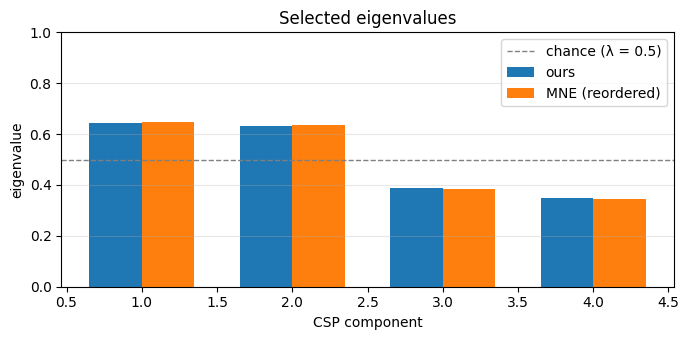

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
idx = np.arange(1, N_COMPONENTS + 1)
w = 0.35
ax.bar(idx - w / 2, ours.eigenvalues_, w, label="ours")
ax.bar(idx + w / 2, mne_evals_aligned, w, label="MNE (reordered)")
ax.axhline(0.5, color="0.5", ls="--", lw=1, label="chance (λ = 0.5)")
ax.set_xlabel("CSP component")
ax.set_ylabel("eigenvalue")
ax.set_title("Selected eigenvalues")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()


## 5. Spatial filters — cosine similarity

Because sign is free, compare `|cos(w_ours, w_mne)|`. A value near 1 means the two filters point along the same axis (possibly flipped).


In [8]:
print("component   |cos|")
cosines = []
for i in range(N_COMPONENTS):
    c = abs_cosine(ours.filters_[i], mne_filters_aligned[i])
    cosines.append(c)
    print(f"    {i}        {c:.4f}")
print()
print("mean |cos| :", round(float(np.mean(cosines)), 4))


component   |cos|
    0        0.9871
    1        0.9888
    2        0.9932
    3        0.9931

mean |cos| : 0.9906


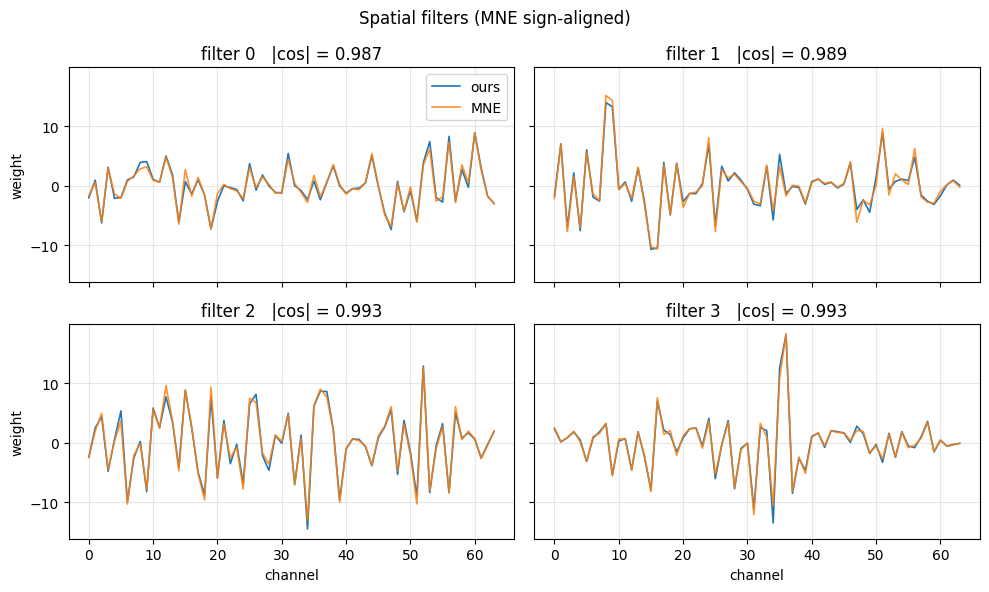

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
ch = np.arange(ours.n_channels_)
for i, ax in enumerate(axes.ravel()):
    w_ours = ours.filters_[i]
    w_mne = mne_filters_aligned[i]
    if np.dot(w_ours, w_mne) < 0:
        w_mne = -w_mne
    ax.plot(ch, w_ours, lw=1.2, label="ours")
    ax.plot(ch, w_mne, lw=1.2, alpha=0.85, label="MNE")
    ax.set_title(f"filter {i}   |cos| = {cosines[i]:.3f}")
    ax.grid(alpha=0.3)
axes[0, 0].legend(loc="upper right")
axes[1, 0].set_xlabel("channel")
axes[1, 1].set_xlabel("channel")
axes[0, 0].set_ylabel("weight")
axes[1, 0].set_ylabel("weight")
fig.suptitle("Spatial filters (MNE sign-aligned)")
plt.tight_layout()


## 6. Feature space

The two `transform` formulas are **not** the same, so the numbers themselves will differ. What we want is the same **geometry**: the two classes should separate along the same axes.


In [10]:
feat_ours = ours.transform(X)
feat_mne = mne_csp.transform(X)
feat_mne_aligned = feat_mne[:, perm]

print("ours features :", feat_ours.shape, "  mean", np.round(feat_ours.mean(0), 3))
print("MNE  features :", feat_mne.shape, "  mean", np.round(feat_mne.mean(0), 3))
print()
print("Class-wise mean (ours):")
for cls in ours.classes_:
    print(f"  class {cls}: {np.round(feat_ours[y == cls].mean(0), 3)}")
print("Class-wise mean (MNE, original alternate order):")
for cls in ours.classes_:
    print(f"  class {cls}: {np.round(feat_mne[y == cls].mean(0), 3)}")


ours features : (45, 4)   mean [-1.443 -1.42  -1.415 -1.533]
MNE  features : (45, 4)   mean [-18.371 -18.448 -18.337 -18.314]

Class-wise mean (ours):
  class 2: [-1.194 -1.187 -1.649 -1.806]
  class 3: [-1.702 -1.664 -1.169 -1.249]
Class-wise mean (MNE, original alternate order):
  class 2: [-18.105 -18.696 -18.083 -18.524]
  class 3: [-18.65  -18.189 -18.603 -18.095]


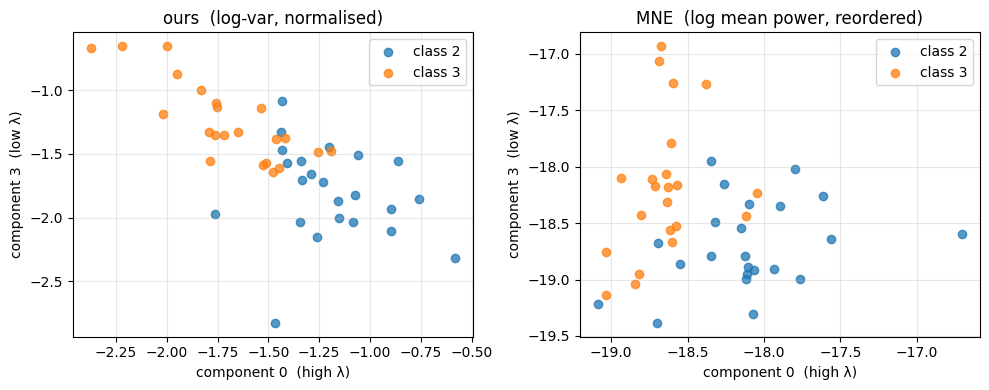

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=False, sharey=False)

for ax, feat, title, xlab, ylab in [
    (axes[0], feat_ours, "ours  (log-var, normalised)", "component 0  (high λ)", "component 3  (low λ)"),
    (axes[1], feat_mne_aligned, "MNE  (log mean power, reordered)", "component 0  (high λ)", "component 3  (low λ)"),
]:
    for cls in np.unique(y):
        mask = y == cls
        ax.scatter(feat[mask, 0], feat[mask, -1], alpha=0.75, label=f"class {cls}")
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()


## 7. Classification accuracy — the actual check

Drop each transformer in front of the same LDA, same 5-fold split. Also run MNE **defaults** (concatenated covariance, no trace-norm, mutual-info order) as a second reference: that is what a typical MNE pipeline would use.


In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)


def cv_scores(csp):
    pipe = Pipeline([
        ("csp", csp),
        ("clf", LinearDiscriminantAnalysis()),
    ])
    return cross_val_score(pipe, X, y, cv=cv)


scores = {
    "ours": cv_scores(CSP(n_components=N_COMPONENTS)),
    "MNE matched": cv_scores(make_mne_csp()),
    "MNE default": cv_scores(MneCSP(n_components=N_COMPONENTS)),
}

print(f"{'transformer':<14} {'folds':<28} {'mean':>6}  {'std':>6}")
for name, s in scores.items():
    print(f"{name:<14} {np.round(s, 3)}  {s.mean():6.3f}  {s.std():6.3f}")


transformer    folds                          mean     std
ours           [0.667 0.556 0.778 0.667 0.889]   0.711   0.113
MNE matched    [0.778 0.556 0.778 0.889 0.667]   0.733   0.113
MNE default    [0.444 0.889 0.889 0.889 0.778]   0.778   0.172


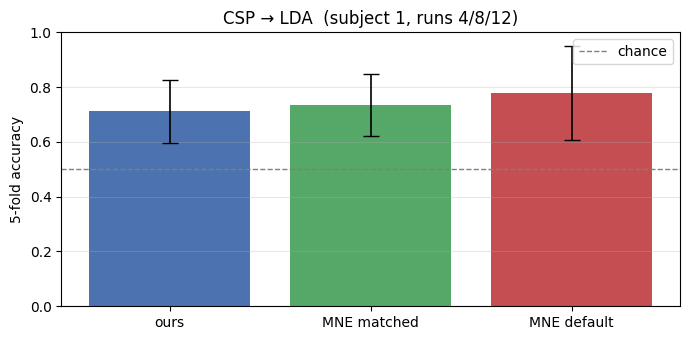

In [13]:
fig, ax = plt.subplots(figsize=(7, 3.5))
names = list(scores)
means = [scores[n].mean() for n in names]
stds = [scores[n].std() for n in names]
colors = ["#4C72B0", "#55A868", "#C44E52"]
ax.bar(names, means, yerr=stds, capsize=6, color=colors, error_kw={"lw": 1.2})
ax.axhline(0.5, color="0.5", ls="--", lw=1, label="chance")
ax.set_ylim(0, 1)
ax.set_ylabel("5-fold accuracy")
ax.set_title("CSP → LDA  (subject 1, runs 4/8/12)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()


**What to remember**

| | ours | MNE (matched) |
|---|---|---|
| filters | `(n_components, n_channels)` | `(n_channels, n_channels)` |
| eigenvalues | close after reordering | close after reordering |
| `\|cos(w)\|` | — | ~0.99 on this subject |
| CV accuracy | same ballpark | same ballpark |

45 trials is a small set, so individual folds jump around. The mean is what we care about, and it already sits well above chance.

Next (Phase 4): wrap this transformer in `Pipeline([("csp", CSP()), ("clf", LDA())])`, then write `train` / `predict` scripts and the `mybci.py` CLI.
